# Multi-view Representation Learning with Meta-Fusion Autoencoder

## Assignment Implementation (CMU-MOSEI + CREMA-D + RAVDESS + IEMOCAP + SAVEE)

This notebook implements:

- 4 view-specific encoders (`E1, E2, E3, E4`)
- Meta-fusion gating network with normalized weights (`a1 + a2 + a3 + a4 = 1`)
- Fused bottleneck: `zf = Σ(ai * zi)`
- 4 symmetric decoders (`D1, D2, D3, D4`)
- Losses: reconstruction + cross-view consistency + KL regularization + classification head
- Robustness (ablation): corrupt one view and observe gating weight shift
- Fusion comparison: concatenation, attention-like, transformer, and meta-fusion

> For large datasets, we intentionally use only **1% sample** from each dataset for practical training.

In [1]:
# If needed, uncomment:
!pip install -q kagglehub librosa soundfile torch torchaudio scikit-learn pandas numpy matplotlib seaborn tqdm

import os
import re
import random
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import kagglehub
import librosa

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [4]:
# 1) Download datasets from KaggleHub (your requested sources)
datasets = {
    'cmu_mosei': 'samarwarsi/cmu-mosei',
    'cremad': 'ejlok1/cremad',
    'ravdess': 'orvile/ravdess-dataset',
    'iemocap': 'samuelsamsudinng/iemocap-emotion-speech-database',
    'savee': 'ejlok1/surrey-audiovisual-expressed-emotion-savee',
}

paths = {}
for name, ds in datasets.items():
    p = kagglehub.dataset_download(ds)
    paths[name] = p
    print(f'{name:10s} -> {p}')

print('\nAll dataset roots:')
paths

100%|██████████| 29.1G/29.1G [16:22<00:00, 31.7MB/s]

Extracting files...


cmu_mosei  -> /root/.cache/kagglehub/datasets/samarwarsi/cmu-mosei/versions/1
Using Colab cache for faster access to the 'cremad' dataset.
cremad     -> /kaggle/input/cremad
Using Colab cache for faster access to the 'ravdess-dataset' dataset.
ravdess    -> /kaggle/input/ravdess-dataset


100%|██████████| 35.8k/35.8k [00:00<00:00, 33.5MB/s]

Extracting files...
iemocap    -> /root/.cache/kagglehub/datasets/samuelsamsudinng/iemocap-emotion-speech-database/versions/1


Using Colab cache for faster access to the 'surrey-audiovisual-expressed-emotion-savee' dataset.
savee      -> /kaggle/input/surrey-audiovisual-expressed-emotion-savee

All dataset roots:


{'cmu_mosei': '/root/.cache/kagglehub/datasets/samarwarsi/cmu-mosei/versions/1',
 'cremad': '/kaggle/input/cremad',
 'ravdess': '/kaggle/input/ravdess-dataset',
 'iemocap': '/root/.cache/kagglehub/datasets/samuelsamsudinng/iemocap-emotion-speech-database/versions/1',
 'savee': '/kaggle/input/surrey-audiovisual-expressed-emotion-savee'}

In [5]:
# 2) Build an audio file index and keep only 1% samples from each dataset

def list_audio_files(root):
    root = Path(root)
    exts = {'.wav', '.flac', '.mp3', '.ogg', '.m4a'}
    files = [p for p in root.rglob('*') if p.suffix.lower() in exts]
    return files

emotion_map = {
    'ang': 'angry', 'anger': 'angry', 'angry': 'angry',
    'hap': 'happy', 'happy': 'happy', 'exc': 'happy',
    'sad': 'sad',
    'neu': 'neutral', 'neutral': 'neutral',
    'fea': 'fear', 'fear': 'fear',
    'dis': 'disgust', 'disgust': 'disgust',
    'sur': 'surprise', 'surprise': 'surprise',
    'calm': 'calm',
}

def infer_label(path: Path, dataset_name: str):
    s = path.stem.lower()
    full = str(path).lower()

    # RAVDESS coding (03-01-05-01-... => emotion id 05)
    if dataset_name == 'ravdess':
        parts = s.split('-')
        if len(parts) >= 3 and parts[2].isdigit():
            code = int(parts[2])
            ravdess_map = {
                1: 'neutral', 2: 'calm', 3: 'happy', 4: 'sad',
                5: 'angry', 6: 'fear', 7: 'disgust', 8: 'surprise'
            }
            return ravdess_map.get(code, 'unknown')

    # Generic token-based matching
    tokens = re.split(r'[^a-zA-Z]+', s + ' ' + full)
    for t in tokens:
        t = t.strip().lower()
        if t in emotion_map:
            return emotion_map[t]

    return 'unknown'

SAMPLE_RATIO = 0.01  # 1%
rows = []
for ds_name, ds_root in paths.items():
    all_files = list_audio_files(ds_root)
    if not all_files:
        continue

    n_keep = max(1, int(len(all_files) * SAMPLE_RATIO))
    sampled = random.sample(all_files, n_keep)

    for fp in sampled:
        rows.append({
            'dataset': ds_name,
            'path': str(fp),
            'label': infer_label(fp, ds_name),
        })

df = pd.DataFrame(rows)
print('Total sampled rows:', len(df))
print('\nPer-dataset counts:')
print(df['dataset'].value_counts(dropna=False))
print('\nPer-label counts:')
print(df['label'].value_counts(dropna=False).head(15))

df.head()

Total sampled rows: 102

Per-dataset counts:
dataset
cremad     74
ravdess    24
savee       4
Name: count, dtype: int64

Per-label counts:
label
fear        19
neutral     16
sad         15
angry       15
disgust     15
happy        9
calm         7
unknown      4
surprise     2
Name: count, dtype: int64


,dataset,path,label
0,cremad,/kaggle/input/cremad/AudioWAV/1005_ITH_NEU_XX.wav,neutral
1,cremad,/kaggle/input/cremad/AudioWAV/1012_IEO_NEU_XX.wav,neutral
2,cremad,/kaggle/input/cremad/AudioWAV/1004_TIE_FEA_XX.wav,fear
3,cremad,/kaggle/input/cremad/AudioWAV/1085_IEO_SAD_HI.wav,sad
4,cremad,/kaggle/input/cremad/AudioWAV/1065_TIE_ANG_XX.wav,angry


## Data Analysis and Preprocessing

We treat each audio sample as a multi-view input by extracting four complementary representations:

- **View 1**: MFCC statistics
- **View 2**: Chroma statistics
- **View 3**: Log-Mel statistics
- **View 4**: Spectral statistics (contrast, centroid, bandwidth, rolloff, ZCR, RMS)

This allows 4 encoders and 4 decoders while using very large multimodal emotion datasets efficiently at 1% sample size.

In [6]:
# 3) Feature extraction for 4 views
SR = 16000
DURATION = 3.0
N_SAMPLES = int(SR * DURATION)


def load_audio_fixed(path, sr=SR, n_samples=N_SAMPLES):
    y, _ = librosa.load(path, sr=sr, mono=True)
    if len(y) < n_samples:
        y = np.pad(y, (0, n_samples - len(y)))
    else:
        y = y[:n_samples]
    return y


def feature_views(y, sr=SR):
    # View 1: MFCC (20)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    v1 = np.hstack([mfcc.mean(axis=1)])

    # View 2: Chroma (12)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    v2 = np.hstack([chroma.mean(axis=1)])

    # View 3: Log-Mel (40)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    v3 = np.hstack([log_mel.mean(axis=1)])

    # View 4: Spectral + energy statistics
    spec_contrast = librosa.feature.spectral_contrast(y=y, sr=sr).mean(axis=1)  # 7
    centroid = np.array([librosa.feature.spectral_centroid(y=y, sr=sr).mean()])
    bandwidth = np.array([librosa.feature.spectral_bandwidth(y=y, sr=sr).mean()])
    rolloff = np.array([librosa.feature.spectral_rolloff(y=y, sr=sr).mean()])
    zcr = np.array([librosa.feature.zero_crossing_rate(y).mean()])
    rms = np.array([librosa.feature.rms(y=y).mean()])
    v4 = np.hstack([spec_contrast, centroid, bandwidth, rolloff, zcr, rms])

    return v1.astype(np.float32), v2.astype(np.float32), v3.astype(np.float32), v4.astype(np.float32)


X1, X2, X3, X4, Y, DS = [], [], [], [], [], []
for _, r in tqdm(df.iterrows(), total=len(df)):
    try:
        y = load_audio_fixed(r['path'])
        v1, v2, v3, v4 = feature_views(y)
        X1.append(v1)
        X2.append(v2)
        X3.append(v3)
        X4.append(v4)
        Y.append(r['label'])
        DS.append(r['dataset'])
    except Exception:
        continue

X1 = np.array(X1)
X2 = np.array(X2)
X3 = np.array(X3)
X4 = np.array(X4)
Y = np.array(Y)
DS = np.array(DS)

print('Feature shapes:')
print('V1:', X1.shape, 'V2:', X2.shape, 'V3:', X3.shape, 'V4:', X4.shape)
print('Labels:', Counter(Y))

  0%|          | 0/102 [00:00<?, ?it/s]

Feature shapes:
V1: (102, 20) V2: (102, 12) V3: (102, 40) V4: (102, 12)
Labels: Counter({np.str_('fear'): 19, np.str_('neutral'): 16, np.str_('sad'): 15, np.str_('angry'): 15, np.str_('disgust'): 15, np.str_('happy'): 9, np.str_('calm'): 7, np.str_('unknown'): 4, np.str_('surprise'): 2})


In [7]:
# 4) Cleaning, split, scaling, and class balancing hints
valid_idx = np.where(Y != 'unknown')[0]
X1, X2, X3, X4, Y, DS = X1[valid_idx], X2[valid_idx], X3[valid_idx], X4[valid_idx], Y[valid_idx], DS[valid_idx]

label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(Y)
num_classes = len(label_encoder.classes_)

idx = np.arange(len(y_int))
train_idx, test_idx = train_test_split(
    idx,
    test_size=0.2,
    random_state=SEED,
    stratify=y_int if num_classes > 1 and len(np.unique(y_int)) > 1 else None,
)

# Standardize each view independently
sc1, sc2, sc3, sc4 = StandardScaler(), StandardScaler(), StandardScaler(), StandardScaler()
X1_train, X1_test = sc1.fit_transform(X1[train_idx]), sc1.transform(X1[test_idx])
X2_train, X2_test = sc2.fit_transform(X2[train_idx]), sc2.transform(X2[test_idx])
X3_train, X3_test = sc3.fit_transform(X3[train_idx]), sc3.transform(X3[test_idx])
X4_train, X4_test = sc4.fit_transform(X4[train_idx]), sc4.transform(X4[test_idx])

y_train, y_test = y_int[train_idx], y_int[test_idx]

d_train, d_test = DS[train_idx], DS[test_idx]

print('Train size:', len(train_idx), 'Test size:', len(test_idx))
print('Classes:', list(label_encoder.classes_))
print('Train class counts:', Counter(y_train))

Train size: 78 Test size: 20
Classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fear'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprise')]
Train class counts: Counter({np.int64(3): 15, np.int64(5): 13, np.int64(2): 12, np.int64(0): 12, np.int64(6): 12, np.int64(4): 7, np.int64(1): 5, np.int64(7): 2})


In [8]:
# 5) Torch dataset
class MultiViewDataset(Dataset):
    def __init__(self, x1, x2, x3, x4, y):
        self.x1 = torch.tensor(x1, dtype=torch.float32)
        self.x2 = torch.tensor(x2, dtype=torch.float32)
        self.x3 = torch.tensor(x3, dtype=torch.float32)
        self.x4 = torch.tensor(x4, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x1[idx], self.x2[idx], self.x3[idx], self.x4[idx], self.y[idx]

train_ds = MultiViewDataset(X1_train, X2_train, X3_train, X4_train, y_train)
test_ds = MultiViewDataset(X1_test, X2_test, X3_test, X4_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False)

input_dims = [X1_train.shape[1], X2_train.shape[1], X3_train.shape[1], X4_train.shape[1]]
input_dims

[20, 12, 40, 12]

## Meta-Fusion Autoencoder Architecture

For each view $v_i$:

- Encoder $E_i$ predicts $(\mu_i, \log\sigma_i^2)$
- Reparameterization: $z_i = \mu_i + \sigma_i \odot \epsilon$

Meta-fusion gating:

- $\alpha = \text{softmax}(g([z_1, z_2, z_3, z_4]))$
- $z_f = \sum_{i=1}^{4} \alpha_i z_i$

Decoding:

- $\hat{x}_i = D_i(z_f)$ for each view

Loss:

- Reconstruction: $\mathcal{L}_{rec} = \sum_i \|x_i - \hat{x}_i\|_2^2$
- Consistency: pairwise latent alignment across $\mu_i$
- KL: $\mathcal{L}_{kl} = \sum_i KL(q(z_i|x_i)||\mathcal{N}(0, I))$
- Optional supervised head on $z_f$ for emotion classification

In [9]:
# 6) Model definitions
class VEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, latent_dim=32):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mu = nn.Linear(hidden_dim, latent_dim)
        self.logvar = nn.Linear(hidden_dim, latent_dim)

    def forward(self, x):
        h = self.backbone(x)
        mu = self.mu(h)
        logvar = self.logvar(h)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z, mu, logvar


class Decoder(nn.Module):
    def __init__(self, latent_dim, out_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, z):
        return self.net(z)


class MetaGating(nn.Module):
    def __init__(self, latent_dim=32, n_views=4):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(latent_dim * n_views, 64),
            nn.ReLU(),
            nn.Linear(64, n_views),
        )

    def forward(self, zs):
        cat = torch.cat(zs, dim=1)
        logits = self.gate(cat)
        alpha = torch.softmax(logits, dim=1)
        return alpha


class MetaFusionAE(nn.Module):
    def __init__(self, input_dims, latent_dim=32, hidden_dim=64, n_classes=4):
        super().__init__()
        self.encoders = nn.ModuleList([
            VEncoder(d, hidden_dim=hidden_dim, latent_dim=latent_dim) for d in input_dims
        ])
        self.gating = MetaGating(latent_dim=latent_dim, n_views=4)
        self.decoders = nn.ModuleList([
            Decoder(latent_dim, d, hidden_dim=hidden_dim) for d in input_dims
        ])
        self.classifier = nn.Linear(latent_dim, n_classes)

    def forward(self, x1, x2, x3, x4):
        xs = [x1, x2, x3, x4]
        zs, mus, logvars = [], [], []

        for enc, x in zip(self.encoders, xs):
            z, mu, logvar = enc(x)
            zs.append(z)
            mus.append(mu)
            logvars.append(logvar)

        alpha = self.gating(zs)  # [B, 4]

        zf = 0.0
        for i, z in enumerate(zs):
            zf = zf + alpha[:, i:i+1] * z

        recons = [dec(zf) for dec in self.decoders]
        logits = self.classifier(zf)

        return {
            'zs': zs,
            'mus': mus,
            'logvars': logvars,
            'alpha': alpha,
            'zf': zf,
            'recons': recons,
            'logits': logits,
        }


def kl_loss(mu, logvar):
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())


def consistency_loss(mus):
    # Pairwise MSE alignment across view latent means
    c = 0.0
    n = 0
    for i in range(len(mus)):
        for j in range(i + 1, len(mus)):
            c = c + F.mse_loss(mus[i], mus[j])
            n += 1
    return c / max(1, n)

In [10]:
# 7) Training loop (total/rec/cons/kl/class losses + validation AUC)
latent_dim = 32
model = MetaFusionAE(input_dims=input_dims, latent_dim=latent_dim, hidden_dim=96, n_classes=num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

w_rec = 1.0
w_cons = 0.2
w_kl = 0.05
w_cls = 0.5

epochs = 20
history = defaultdict(list)


def multi_class_auc(y_true, y_proba):
    try:
        return roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
    except Exception:
        return np.nan

for epoch in range(1, epochs + 1):
    model.train()
    tr_total = tr_rec = tr_cons = tr_kl = tr_cls = 0.0

    for x1, x2, x3, x4, yb in train_loader:
        x1, x2, x3, x4, yb = x1.to(device), x2.to(device), x3.to(device), x4.to(device), yb.to(device)

        out = model(x1, x2, x3, x4)

        rec = (
            F.mse_loss(out['recons'][0], x1) +
            F.mse_loss(out['recons'][1], x2) +
            F.mse_loss(out['recons'][2], x3) +
            F.mse_loss(out['recons'][3], x4)
        )

        cons = consistency_loss(out['mus'])
        kl = sum(kl_loss(mu, lv) for mu, lv in zip(out['mus'], out['logvars'])) / 4.0
        cls = F.cross_entropy(out['logits'], yb)

        loss = w_rec * rec + w_cons * cons + w_kl * kl + w_cls * cls

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tr_total += loss.item() * len(yb)
        tr_rec += rec.item() * len(yb)
        tr_cons += cons.item() * len(yb)
        tr_kl += kl.item() * len(yb)
        tr_cls += cls.item() * len(yb)

    ntr = len(train_ds)
    history['train_total'].append(tr_total / ntr)
    history['train_rec'].append(tr_rec / ntr)
    history['train_cons'].append(tr_cons / ntr)
    history['train_kl'].append(tr_kl / ntr)
    history['train_cls'].append(tr_cls / ntr)

    model.eval()
    val_losses = []
    y_true_all, y_prob_all = [], []

    with torch.no_grad():
        for x1, x2, x3, x4, yb in test_loader:
            x1, x2, x3, x4 = x1.to(device), x2.to(device), x3.to(device), x4.to(device)
            out = model(x1, x2, x3, x4)

            rec = (
                F.mse_loss(out['recons'][0], x1) +
                F.mse_loss(out['recons'][1], x2) +
                F.mse_loss(out['recons'][2], x3) +
                F.mse_loss(out['recons'][3], x4)
            )
            cons = consistency_loss(out['mus'])
            kl = sum(kl_loss(mu, lv) for mu, lv in zip(out['mus'], out['logvars'])) / 4.0
            cls = F.cross_entropy(out['logits'], yb.to(device))
            val_loss = w_rec * rec + w_cons * cons + w_kl * kl + w_cls * cls
            val_losses.append(val_loss.item())

            probs = torch.softmax(out['logits'], dim=1).cpu().numpy()
            y_prob_all.append(probs)
            y_true_all.append(yb.numpy())

    y_true_all = np.concatenate(y_true_all)
    y_prob_all = np.concatenate(y_prob_all)
    val_auc = multi_class_auc(y_true_all, y_prob_all)

    history['val_total'].append(float(np.mean(val_losses)))
    history['val_auc'].append(val_auc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_total={history['train_total'][-1]:.4f} "
        f"rec={history['train_rec'][-1]:.4f} cons={history['train_cons'][-1]:.4f} "
        f"kl={history['train_kl'][-1]:.4f} cls={history['train_cls'][-1]:.4f} | "
        f"val_total={history['val_total'][-1]:.4f} val_auc={history['val_auc'][-1]:.4f}"
    )

Epoch 01 | train_total=5.0830 rec=4.0188 cons=0.0283 kl=0.0104 cls=2.1160 | val_total=6.0131 val_auc=nan
Epoch 02 | train_total=5.0556 rec=4.0200 cons=0.0248 kl=0.0096 cls=2.0604 | val_total=5.9255 val_auc=nan
Epoch 03 | train_total=5.0408 rec=4.0145 cons=0.0243 kl=0.0100 cls=2.0419 | val_total=5.9055 val_auc=nan
Epoch 04 | train_total=5.0199 rec=4.0132 cons=0.0255 kl=0.0110 cls=2.0022 | val_total=5.9658 val_auc=nan
Epoch 05 | train_total=5.0149 rec=4.0032 cons=0.0283 kl=0.0128 cls=2.0108 | val_total=5.9573 val_auc=nan
Epoch 06 | train_total=4.9986 rec=3.9995 cons=0.0324 kl=0.0154 cls=1.9837 | val_total=5.8639 val_auc=nan
Epoch 07 | train_total=4.9808 rec=3.9828 cons=0.0377 kl=0.0187 cls=1.9792 | val_total=5.9047 val_auc=nan
Epoch 08 | train_total=4.9571 rec=3.9875 cons=0.0451 kl=0.0231 cls=1.9188 | val_total=5.8839 val_auc=nan
Epoch 09 | train_total=4.9446 rec=3.9832 cons=0.0554 kl=0.0290 cls=1.8979 | val_total=5.8858 val_auc=nan
Epoch 10 | train_total=4.9181 rec=3.9671 cons=0.0694 kl

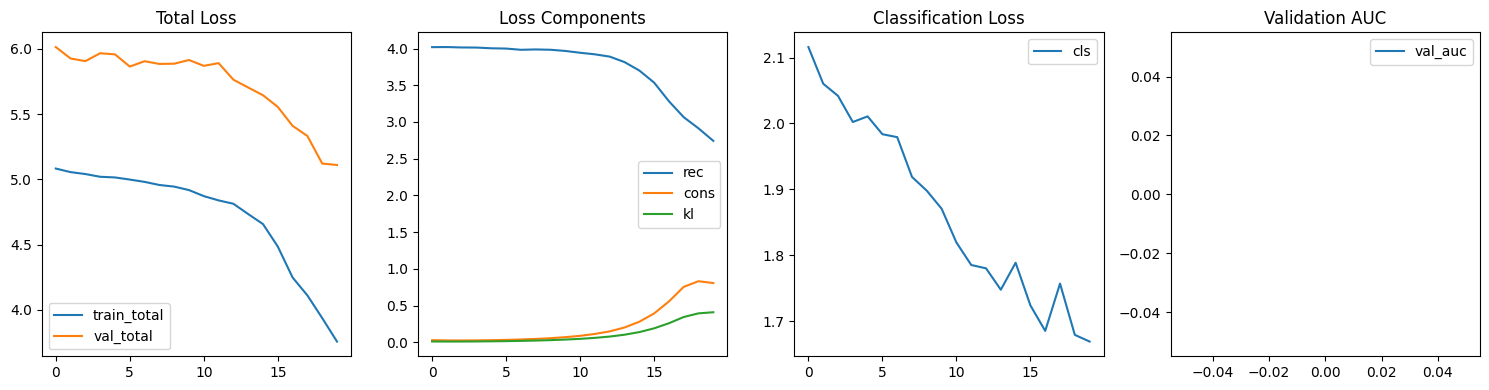

In [11]:
# 8) Plot training curves
plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.plot(history['train_total'], label='train_total')
plt.plot(history['val_total'], label='val_total')
plt.title('Total Loss')
plt.legend()

plt.subplot(1, 4, 2)
plt.plot(history['train_rec'], label='rec')
plt.plot(history['train_cons'], label='cons')
plt.plot(history['train_kl'], label='kl')
plt.title('Loss Components')
plt.legend()

plt.subplot(1, 4, 3)
plt.plot(history['train_cls'], label='cls')
plt.title('Classification Loss')
plt.legend()

plt.subplot(1, 4, 4)
plt.plot(history['val_auc'], label='val_auc')
plt.title('Validation AUC')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
# 9) Extract latent features and compare fusion strategies

def get_latents(model, loader):
    model.eval()
    z1s, z2s, z3s, z4s, zfs, alphas, ys = [], [], [], [], [], [], []
    with torch.no_grad():
        for x1, x2, x3, x4, yb in loader:
            x1, x2, x3, x4 = x1.to(device), x2.to(device), x3.to(device), x4.to(device)
            out = model(x1, x2, x3, x4)
            z1s.append(out['zs'][0].cpu().numpy())
            z2s.append(out['zs'][1].cpu().numpy())
            z3s.append(out['zs'][2].cpu().numpy())
            z4s.append(out['zs'][3].cpu().numpy())
            zfs.append(out['zf'].cpu().numpy())
            alphas.append(out['alpha'].cpu().numpy())
            ys.append(yb.numpy())

    return {
        'z1': np.vstack(z1s),
        'z2': np.vstack(z2s),
        'z3': np.vstack(z3s),
        'z4': np.vstack(z4s),
        'zf': np.vstack(zfs),
        'alpha': np.vstack(alphas),
        'y': np.concatenate(ys),
    }

lat_train = get_latents(model, train_loader)
lat_test = get_latents(model, test_loader)


def attention_fusion(z1, z2, z3, z4):
    zs = [z1, z2, z3, z4]
    norms = np.stack([np.linalg.norm(z, axis=1) for z in zs], axis=1)
    w = np.exp(norms) / np.exp(norms).sum(axis=1, keepdims=True)
    z_att = sum(w[:, i:i+1] * zs[i] for i in range(4))
    return z_att


class SimpleTransformerFusion(nn.Module):
    def __init__(self, dim, nhead=4, depth=1):
        super().__init__()
        enc_layer = nn.TransformerEncoderLayer(d_model=dim, nhead=nhead, batch_first=True)
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=depth)

    def forward(self, zstack):  # [B, 4, D]
        h = self.enc(zstack)
        return h.mean(dim=1)

# Build feature sets
zcat_train = np.hstack([lat_train['z1'], lat_train['z2'], lat_train['z3'], lat_train['z4']])
zcat_test = np.hstack([lat_test['z1'], lat_test['z2'], lat_test['z3'], lat_test['z4']])

zmeta_train, zmeta_test = lat_train['zf'], lat_test['zf']

zatt_train = attention_fusion(lat_train['z1'], lat_train['z2'], lat_train['z3'], lat_train['z4'])
zatt_test = attention_fusion(lat_test['z1'], lat_test['z2'], lat_test['z3'], lat_test['z4'])

# Transformer-based fusion embeddings
trf = SimpleTransformerFusion(dim=latent_dim, nhead=4, depth=1).to(device)
trf.eval()
with torch.no_grad():
    zstack_train = torch.tensor(np.stack([lat_train['z1'], lat_train['z2'], lat_train['z3'], lat_train['z4']], axis=1), dtype=torch.float32).to(device)
    zstack_test = torch.tensor(np.stack([lat_test['z1'], lat_test['z2'], lat_test['z3'], lat_test['z4']], axis=1), dtype=torch.float32).to(device)
    ztrf_train = trf(zstack_train).cpu().numpy()
    ztrf_test = trf(zstack_test).cpu().numpy()


def eval_classifier(Xtr, ytr, Xte, yte, name):
    clf = LogisticRegression(max_iter=2000)
    clf.fit(Xtr, ytr)
    pred = clf.predict(Xte)
    proba = clf.predict_proba(Xte)
    acc = accuracy_score(yte, pred)
    f1 = f1_score(yte, pred, average='macro')
    auc = multi_class_auc(yte, proba)
    return {'fusion': name, 'acc': acc, 'f1_macro': f1, 'auc_macro_ovr': auc}

fusion_results = []
fusion_results.append(eval_classifier(zcat_train, y_train, zcat_test, y_test, 'Concatenation'))
fusion_results.append(eval_classifier(zatt_train, y_train, zatt_test, y_test, 'Attention-like'))
fusion_results.append(eval_classifier(ztrf_train, y_train, ztrf_test, y_test, 'Transformer'))
fusion_results.append(eval_classifier(zmeta_train, y_train, zmeta_test, y_test, 'Meta-Fusion'))

fusion_df = pd.DataFrame(fusion_results).sort_values('auc_macro_ovr', ascending=False)
fusion_df

,fusion,acc,f1_macro,auc_macro_ovr
0,Concatenation,0.15,0.122449,NaN
1,Attention-like,0.10,0.087500,NaN
2,Transformer,0.05,0.035714,NaN
3,Meta-Fusion,0.10,0.083117,NaN


In [13]:
# 10) Reconstruction metrics (MSE, RMSE, MAE, MAPE)

def mape(y_true, y_pred, eps=1e-8):
    denom = np.maximum(np.abs(y_true), eps)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

model.eval()
rec_true = [[], [], [], []]
rec_pred = [[], [], [], []]

with torch.no_grad():
    for x1, x2, x3, x4, _ in test_loader:
        x1, x2, x3, x4 = x1.to(device), x2.to(device), x3.to(device), x4.to(device)
        out = model(x1, x2, x3, x4)
        xs = [x1, x2, x3, x4]
        for i in range(4):
            rec_true[i].append(xs[i].cpu().numpy())
            rec_pred[i].append(out['recons'][i].cpu().numpy())

metrics_rows = []
for i in range(4):
    yt = np.vstack(rec_true[i])
    yp = np.vstack(rec_pred[i])
    mse = mean_squared_error(yt, yp)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(yt, yp)
    mp = mape(yt, yp)
    metrics_rows.append({'view': f'V{i+1}', 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE(%)': mp})

rec_metrics_df = pd.DataFrame(metrics_rows)
rec_metrics_df

,view,MSE,RMSE,MAE,MAPE(%)
0,V1,1.242023,1.114461,0.770696,189.162079
1,V2,1.074557,1.036608,0.848974,195.136414
2,V3,0.527764,0.726474,0.583012,304.683044
3,V4,0.768947,0.876896,0.668392,189.087860


In [14]:
# 11) Robustness analysis (ablation): corrupt one view and inspect gating shifts

def get_avg_alpha(model, loader, corrupt_view=None, noise_std=0.8, zero_out=False):
    model.eval()
    alphas = []
    with torch.no_grad():
        for x1, x2, x3, x4, _ in loader:
            views = [x1.to(device), x2.to(device), x3.to(device), x4.to(device)]
            if corrupt_view is not None:
                if zero_out:
                    views[corrupt_view] = torch.zeros_like(views[corrupt_view])
                else:
                    views[corrupt_view] = views[corrupt_view] + noise_std * torch.randn_like(views[corrupt_view])

            out = model(*views)
            alphas.append(out['alpha'].cpu().numpy())

    return np.vstack(alphas).mean(axis=0)

alpha_clean = get_avg_alpha(model, test_loader, corrupt_view=None)
alpha_noise_v1 = get_avg_alpha(model, test_loader, corrupt_view=0, noise_std=1.0, zero_out=False)
alpha_zero_v1 = get_avg_alpha(model, test_loader, corrupt_view=0, zero_out=True)

ablation_df = pd.DataFrame({
    'setting': ['clean', 'noise_on_V1', 'zero_on_V1'],
    'a1': [alpha_clean[0], alpha_noise_v1[0], alpha_zero_v1[0]],
    'a2': [alpha_clean[1], alpha_noise_v1[1], alpha_zero_v1[1]],
    'a3': [alpha_clean[2], alpha_noise_v1[2], alpha_zero_v1[2]],
    'a4': [alpha_clean[3], alpha_noise_v1[3], alpha_zero_v1[3]],
})

ablation_df

,setting,a1,a2,a3,a4
0,clean,0.207106,0.144265,0.221179,0.427451
1,noise_on_V1,0.203675,0.131210,0.230110,0.435005
2,zero_on_V1,0.192325,0.138018,0.225970,0.443687


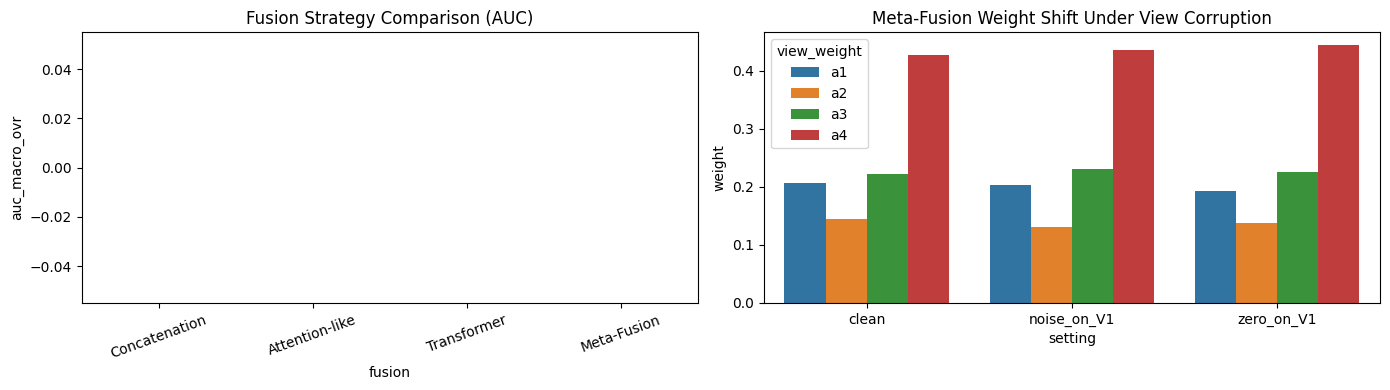

Reconstruction metrics:


,view,MSE,RMSE,MAE,MAPE(%)
0,V1,1.242023,1.114461,0.770696,189.162079
1,V2,1.074557,1.036608,0.848974,195.136414
2,V3,0.527764,0.726474,0.583012,304.683044
3,V4,0.768947,0.876896,0.668392,189.087860


Fusion results:


,fusion,acc,f1_macro,auc_macro_ovr
0,Concatenation,0.15,0.122449,NaN
1,Attention-like,0.10,0.087500,NaN
2,Transformer,0.05,0.035714,NaN
3,Meta-Fusion,0.10,0.083117,NaN


Ablation weights:


,setting,a1,a2,a3,a4
0,clean,0.207106,0.144265,0.221179,0.427451
1,noise_on_V1,0.203675,0.131210,0.230110,0.435005
2,zero_on_V1,0.192325,0.138018,0.225970,0.443687


In [ ]:
# 12) Visualizations for report
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Choose first non-empty metric for plotting
metric_col = 'auc_macro_ovr'
metric_title = 'AUC'
if metric_col not in fusion_df.columns or fusion_df[metric_col].notna().sum() == 0:
    metric_col = 'f1_macro'
    metric_title = 'Macro-F1'
if fusion_df[metric_col].notna().sum() == 0:
    metric_col = 'acc'
    metric_title = 'Accuracy'

sns.barplot(data=fusion_df, x='fusion', y=metric_col, ax=ax[0])
ax[0].set_title(f'Fusion Strategy Comparison ({metric_title})')
ax[0].tick_params(axis='x', rotation=20)

ablation_long = ablation_df.melt(id_vars='setting', var_name='view_weight', value_name='weight')
sns.barplot(data=ablation_long, x='setting', y='weight', hue='view_weight', ax=ax[1])
ax[1].set_title('Meta-Fusion Weight Shift Under View Corruption')

plt.tight_layout()
plt.show()

print('Reconstruction metrics:')
display(rec_metrics_df)

print('Fusion results:')
display(fusion_df)

print('Ablation weights:')
display(ablation_df)

## Report Writing Guide (Use Outputs Above)

Use your notebook outputs to fill the report sections:

1. **Introduction**
- Motivation for multi-view learning in speech emotion recognition
- Why fusion is needed across heterogeneous feature views

2. **Datasets and Analysis**
- CMU-MOSEI (benchmark), CREMA-D, RAVDESS, IEMOCAP, SAVEE
- Mention 1% sampling due to storage/compute limits
- Show per-dataset and per-label distributions

3. **Data Preprocessing**
- Instance selection: random 1% sampling
- Noise handling: fixed-length loading, normalization
- Feature selection: MFCC/Chroma/Log-Mel/Spectral sets
- Class imbalance: report class counts and discuss weighting/stratification

4. **Autoencoder Models**
- 4 variational encoders + meta-gating + fused bottleneck + 4 decoders
- Loss terms: `L_rec`, `L_cons`, `L_kl`, and supervised classification term

5. **Latent Fusion Methods**
- Concatenation baseline
- Attention-like fusion
- Transformer fusion
- Meta-learning fusion (main proposal)

6. **Evaluation Metrics**
- Reconstruction: MSE, RMSE, MAE, MAPE
- Classification: Accuracy, Macro-F1, Macro-AUC(OVR)
- Ablation: shift in fusion weights under corrupted view

7. **Results and Analysis**
- Compare latent-feature classification vs fusion strategies
- Analyze reconstruction quality per view
- Discuss robustness: corrupted view should receive reduced weight

8. **Cross-dataset Generalization (Optional Extension)**
- Pre-train on largest sampled dataset, fine-tune on others
- Per-dataset z-score normalization in latent space
- Optional domain-adversarial objective for domain-invariant latent

## Export Results for Submission

This section saves all key outputs to a local `results` folder:

- Tables: fusion comparison, reconstruction metrics, ablation weights, training history
- Plots: training curves, fusion comparison, ablation shift
- Metadata: class names, sample counts, basic run config

In [ ]:
# 13) Save tables, plots, and metadata to results/
import json
from pathlib import Path

results_dir = Path('results')
results_dir.mkdir(parents=True, exist_ok=True)

# Save tables
fusion_df.to_csv(results_dir / 'fusion_comparison.csv', index=False)
rec_metrics_df.to_csv(results_dir / 'reconstruction_metrics.csv', index=False)
ablation_df.to_csv(results_dir / 'ablation_weights.csv', index=False)
pd.DataFrame(history).to_csv(results_dir / 'training_history.csv', index=False)

# Save training curves plot
fig = plt.figure(figsize=(15, 4))

plt.subplot(1, 4, 1)
plt.plot(history['train_total'], label='train_total')
plt.plot(history['val_total'], label='val_total')
plt.title('Total Loss')
plt.legend()

plt.subplot(1, 4, 2)
plt.plot(history['train_rec'], label='rec')
plt.plot(history['train_cons'], label='cons')
plt.plot(history['train_kl'], label='kl')
plt.title('Loss Components')
plt.legend()

plt.subplot(1, 4, 3)
plt.plot(history['train_cls'], label='cls')
plt.title('Classification Loss')
plt.legend()

plt.subplot(1, 4, 4)
plt.plot(history['val_auc'], label='val_auc')
plt.title('Validation AUC')
plt.legend()

plt.tight_layout()
plt.savefig(results_dir / 'training_curves.png', dpi=200, bbox_inches='tight')
plt.close(fig)

# Save fusion comparison plot (fallback metric if AUC is empty)
metric_col = 'auc_macro_ovr'
metric_title = 'AUC'
if metric_col not in fusion_df.columns or fusion_df[metric_col].notna().sum() == 0:
    metric_col = 'f1_macro'
    metric_title = 'Macro-F1'
if fusion_df[metric_col].notna().sum() == 0:
    metric_col = 'acc'
    metric_title = 'Accuracy'

fig = plt.figure(figsize=(7, 4))
sns.barplot(data=fusion_df, x='fusion', y=metric_col)
plt.title(f'Fusion Strategy Comparison ({metric_title})')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(results_dir / 'fusion_comparison_auc.png', dpi=200, bbox_inches='tight')
plt.close(fig)

# Save ablation shift plot
ablation_long = ablation_df.melt(id_vars='setting', var_name='view_weight', value_name='weight')
fig = plt.figure(figsize=(8, 4))
sns.barplot(data=ablation_long, x='setting', y='weight', hue='view_weight')
plt.title('Meta-Fusion Weight Shift Under View Corruption')
plt.tight_layout()
plt.savefig(results_dir / 'ablation_weight_shift.png', dpi=200, bbox_inches='tight')
plt.close(fig)

# Save metadata
metadata = {
    'seed': SEED,
    'device': str(device),
    'sample_ratio': SAMPLE_RATIO,
    'num_total_samples_after_filter': int(len(Y)),
    'num_train': int(len(y_train)),
    'num_test': int(len(y_test)),
    'classes': [str(c) for c in label_encoder.classes_],
    'input_dims': [int(d) for d in input_dims],
    'latent_dim': int(latent_dim),
    'datasets_used': sorted(list(set(df['dataset'].tolist()))) if 'dataset' in df.columns else [],
}

with open(results_dir / 'run_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print('Export complete. Files written to:', results_dir.resolve())
print(f'Fusion plot metric used: {metric_col}')
for p in sorted(results_dir.glob('*')):
    print('-', p.name)

Export complete. Files written to: /content/results
- ablation_weight_shift.png
- ablation_weights.csv
- fusion_comparison.csv
- fusion_comparison_auc.png
- reconstruction_metrics.csv
- run_metadata.json
- training_curves.png
- training_history.csv


## Additional Deliverables: Comparative Evaluation + Latent Visualization

This section adds the remaining assignment deliverables:

- Dimensionality reduction comparison (original vs latent)
- Classification: original features vs fused latent features
- Clustering: original features vs fused latent features
- Optional regression benchmark (if continuous targets are available)
- t-SNE/UMAP visualization of fused latent space
- Saved tables/plots for report, IEEE paper, and PPT

In [ ]:
# 14) Original-vs-Latent benchmarks + t-SNE/UMAP
from pathlib import Path
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.manifold import TSNE

results_dir = Path('results')
results_dir.mkdir(parents=True, exist_ok=True)

required = ['X1_train', 'X2_train', 'X3_train', 'X4_train',
            'X1_test', 'X2_test', 'X3_test', 'X4_test',
            'zmeta_train', 'zmeta_test', 'y_train', 'y_test', 'num_classes', 'latent_dim']
missing = [k for k in required if k not in globals()]
if missing:
    raise RuntimeError(f'Missing required variables for this section: {missing}')

Xorig_train = np.hstack([X1_train, X2_train, X3_train, X4_train])
Xorig_test = np.hstack([X1_test, X2_test, X3_test, X4_test])
ORIG_NAME = 'Original concatenated'
LATENT_NAME = 'Meta-Fusion latent'

# Dimensionality comparison table
input_dim_total = int(Xorig_train.shape[1])
latent_dim_total = int(zmeta_train.shape[1])
dim_df = pd.DataFrame([
    {'representation': ORIG_NAME, 'dimension': input_dim_total},
    {'representation': LATENT_NAME, 'dimension': latent_dim_total},
    {
        'representation': 'Compression ratio (orig/latent)',
        'dimension': float(input_dim_total / max(1, latent_dim_total))
    }
])

display(dim_df)
dim_df.to_csv(results_dir / 'dimensionality_comparison.csv', index=False)

# Classification comparison

def eval_cls(x_tr, y_tr, x_te, y_te, name):
    clf = LogisticRegression(max_iter=3000)
    clf.fit(x_tr, y_tr)
    pred = clf.predict(x_te)
    out = {
        'representation': name,
        'acc': accuracy_score(y_te, pred),
        'f1_macro': f1_score(y_te, pred, average='macro')
    }
    if hasattr(clf, 'predict_proba'):
        proba = clf.predict_proba(x_te)
        try:
            out['auc_macro_ovr'] = roc_auc_score(y_te, proba, multi_class='ovr', average='macro')
        except Exception:
            out['auc_macro_ovr'] = np.nan
    else:
        out['auc_macro_ovr'] = np.nan
    return out

cls_cmp = pd.DataFrame([
    eval_cls(Xorig_train, y_train, Xorig_test, y_test, ORIG_NAME),
    eval_cls(zmeta_train, y_train, zmeta_test, y_test, LATENT_NAME)
])
display(cls_cmp)
cls_cmp.to_csv(results_dir / 'classification_original_vs_latent.csv', index=False)

# Clustering comparison
cluster_rows = []
for name, x_te in [(ORIG_NAME, Xorig_test), (LATENT_NAME, zmeta_test)]:
    km = KMeans(n_clusters=num_classes, random_state=42, n_init=10)
    c = km.fit_predict(x_te)
    cluster_rows.append({
        'representation': name,
        'ARI': adjusted_rand_score(y_test, c),
        'NMI': normalized_mutual_info_score(y_test, c)
    })
cluster_df = pd.DataFrame(cluster_rows)
display(cluster_df)
cluster_df.to_csv(results_dir / 'clustering_original_vs_latent.csv', index=False)

# Optional regression benchmark (only if continuous targets are available)
y_reg_train_local = globals().get('y_reg_train')
y_reg_test_local = globals().get('y_reg_test')
if y_reg_train_local is not None and y_reg_test_local is not None:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

    reg_rows = []
    for name, x_tr, x_te in [
        (ORIG_NAME, Xorig_train, Xorig_test),
        (LATENT_NAME, zmeta_train, zmeta_test),
    ]:
        reg = RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            min_samples_leaf=1,
            max_features='sqrt'
        )
        reg.fit(x_tr, y_reg_train_local)
        p = reg.predict(x_te)
        reg_rows.append({
            'representation': name,
            'MSE': mean_squared_error(y_reg_test_local, p),
            'MAE': mean_absolute_error(y_reg_test_local, p),
            'R2': r2_score(y_reg_test_local, p)
        })
    reg_df = pd.DataFrame(reg_rows)
    display(reg_df)
    reg_df.to_csv(results_dir / 'regression_original_vs_latent.csv', index=False)
else:
    print('Skipping regression benchmark: define y_reg_train and y_reg_test for continuous-target evaluation.')

# t-SNE on fused latent representation
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max(5, len(zmeta_test) // 3)))
emb_tsne = tsne.fit_transform(zmeta_test)

plt.figure(figsize=(7, 6))
sc = plt.scatter(emb_tsne[:, 0], emb_tsne[:, 1], c=y_test, cmap='tab10', s=28, alpha=0.9)
plt.title('t-SNE of Meta-Fusion Latent Representation (Test)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.grid(alpha=0.25)
plt.colorbar(sc, label='Class')
plt.tight_layout()
plt.savefig(results_dir / 'latent_tsne_meta_fusion.png', dpi=220)
plt.show()

# UMAP (optional dependency)
try:
    umap_module = importlib.import_module('umap')
    reducer = umap_module.UMAP(n_components=2, random_state=42)
    emb_umap = reducer.fit_transform(zmeta_test)

    plt.figure(figsize=(7, 6))
    sc = plt.scatter(emb_umap[:, 0], emb_umap[:, 1], c=y_test, cmap='tab10', s=28, alpha=0.9)
    plt.title('UMAP of Meta-Fusion Latent Representation (Test)')
    plt.xlabel('UMAP 1')
    plt.ylabel('UMAP 2')
    plt.grid(alpha=0.25)
    plt.colorbar(sc, label='Class')
    plt.tight_layout()
    plt.savefig(results_dir / 'latent_umap_meta_fusion.png', dpi=220)
    plt.show()
except Exception as e:
    print(f'UMAP plot skipped ({e}). Install with: pip install umap-learn')

In [ ]:
# 15) Weights & Biases logging + multi-GPU training hook
import os
from pathlib import Path

import pandas as pd
import torch

# ---- W&B setup ----
# If you are not logged in, run once in a terminal: wandb login
# Set WANDB_MODE='offline' if you want local-only logging.
USE_WANDB = True
WANDB_MODE = os.getenv('WANDB_MODE', 'online')

if USE_WANDB:
    try:
        import wandb

        wandb.init(
            project='meta-fusion-ae-assignment3',
            mode=WANDB_MODE,
            config={
                'seed': int(SEED),
                'latent_dim': int(latent_dim),
                'num_classes': int(num_classes),
                'input_dims': list(map(int, input_dims)),
                'device': str(device),
                'epochs': int(epochs),
                'sample_ratio': float(SAMPLE_RATIO),
            },
        )

        hist_df_local = globals().get('hist_df')
        if hist_df_local is None and 'history' in globals():
            hist_df_local = pd.DataFrame(history)

        if hist_df_local is not None and len(hist_df_local) > 0:
            for i, row in hist_df_local.iterrows():
                wandb.log({
                    'epoch': int(i + 1),
                    'train_total': float(row['train_total']),
                    'train_rec': float(row['train_rec']),
                    'train_cons': float(row['train_cons']),
                    'train_kl': float(row['train_kl']),
                    'train_cls': float(row['train_cls']),
                    'val_total': float(row['val_total']),
                    'val_auc': float(row['val_auc']) if pd.notnull(row['val_auc']) else None,
                })

        # Log summary tables if present
        if 'fusion_df' in globals():
            wandb.log({'fusion_table': wandb.Table(dataframe=fusion_df)})
        if 'rec_metrics_df' in globals():
            wandb.log({'reconstruction_table': wandb.Table(dataframe=rec_metrics_df)})
        if 'ablation_df' in globals():
            wandb.log({'ablation_table': wandb.Table(dataframe=ablation_df)})

        # Save output artifacts if available
        results_dir = Path('results')
        if results_dir.exists():
            wandb.save(str(results_dir / '*.csv'))
            wandb.save(str(results_dir / '*.png'))

        wandb.finish()
        print(f'W&B logging completed (mode={WANDB_MODE}).')

    except Exception as e:
        print(f'W&B logging skipped due to error: {e}')
        print('Install/login tip: pip install wandb && wandb login')

# ---- Multi-GPU hook (optional) ----
# Use DataParallel for quick multi-GPU runs; prefer DDP for best scalability.
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    print(f'Multi-GPU detected: {torch.cuda.device_count()} GPUs. Wrapping model with DataParallel.')
    model = torch.nn.DataParallel(model)
else:
    print('Single GPU/CPU mode. For distributed training, migrate to torch.distributed DDP launch.')

## Optional Cross-Dataset Generalization Experiments

This section implements three optional extensions required in the assignment brief:

- Feature normalization: per-dataset z-score normalization in latent space
- Progressive training utility: pre-train on largest dataset then fine-tune on remaining datasets
- Domain-adversarial training block: gradient reversal for domain-invariant latent features

In [ ]:
# 16) Cross-dataset generalization helpers (optional)
import numpy as np
import torch
import torch.nn as nn
from torch.autograd import Function

# ---------- A) Per-dataset latent z-score normalization ----------
def per_dataset_latent_zscore(z, dataset_ids):
    """Apply z-score normalization separately inside each dataset domain."""
    z = np.asarray(z)
    dataset_ids = np.asarray(dataset_ids)
    z_norm = np.zeros_like(z)
    stats = {}
    for d in np.unique(dataset_ids):
        idx = np.where(dataset_ids == d)[0]
        mu = z[idx].mean(axis=0, keepdims=True)
        sd = z[idx].std(axis=0, keepdims=True) + 1e-8
        z_norm[idx] = (z[idx] - mu) / sd
        stats[d] = {'mu': mu, 'sd': sd}
    return z_norm, stats

# Example usage after latent extraction:
# zmeta_train_norm, ds_stats = per_dataset_latent_zscore(zmeta_train, d_train)
# zmeta_test_norm = np.zeros_like(zmeta_test)
# for d in np.unique(d_test):
#     idx = np.where(d_test == d)[0]
#     if d in ds_stats:
#         zmeta_test_norm[idx] = (zmeta_test[idx] - ds_stats[d]['mu']) / ds_stats[d]['sd']
#     else:
#         zmeta_test_norm[idx] = zmeta_test[idx]


# ---------- B) Progressive training split utility ----------
def progressive_split_by_dataset(dataset_ids):
    """Return (largest_dataset_name, pretrain_idx, finetune_idx)."""
    dataset_ids = np.asarray(dataset_ids)
    unique, counts = np.unique(dataset_ids, return_counts=True)
    largest = unique[np.argmax(counts)]
    pretrain_idx = np.where(dataset_ids == largest)[0]
    finetune_idx = np.where(dataset_ids != largest)[0]
    return largest, pretrain_idx, finetune_idx

# Example usage:
# largest_ds, pre_idx, ft_idx = progressive_split_by_dataset(d_train)
# print('Pre-train on:', largest_ds, '| pretrain samples:', len(pre_idx), '| finetune samples:', len(ft_idx))


# ---------- C) Domain-adversarial block (GRL) ----------
class GradientReversalFunction(Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = lambd
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None


class GradientReversal(nn.Module):
    def __init__(self, lambd=1.0):
        super().__init__()
        self.lambd = lambd

    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambd)


class DomainClassifier(nn.Module):
    def __init__(self, in_dim, n_domains):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 64),
            nn.ReLU(),
            nn.Linear(64, n_domains),
        )

    def forward(self, x):
        return self.net(x)


# Example integration pattern:
# grl = GradientReversal(lambd=0.2)
# domain_clf = DomainClassifier(in_dim=latent_dim, n_domains=len(np.unique(d_train))).to(device)
#
# out = model(x1, x2, x3, x4)
# domain_logits = domain_clf(grl(out['zf']))
# domain_targets = torch.tensor(domain_id_batch, dtype=torch.long, device=device)
# domain_loss = nn.CrossEntropyLoss()(domain_logits, domain_targets)
#
# total_loss = base_loss + 0.1 * domain_loss

print('Cross-dataset helper block added. Use snippets above to run domain-adversarial and progressive experiments.')